# Taylor Series Approximation — Learning Weights & Biases

**Purpose**: Show that Taylor series can approximate *any differentiable function*
by learning polynomial coefficients (weights & biases) from data.

## Core Idea

Maclaurin expansion of $f(x)$ around $x_0 = 0$:

$$T_n(x) = \sum_{k=0}^{n} \frac{f^{(k)}(0)}{k!}\, x^k
= \underbrace{w_0}_{\text{bias}} + w_1 x + w_2 x^2 + \cdots + w_n x^n$$

**Instead of computing derivatives analytically**, we *learn* the weights $w_k$
from data — using sklearn's polynomial regression **and** hand-rolled gradient descent.

| Order | Model | Notes |
|:---:|:---|:---|
| 1st | $w_0 + w_1 x$ | Best-fit line through the data |
| 2nd | $w_0 + w_1 x + w_2 x^2$ | Adds curvature |
| 3rd | $+\; w_3 x^3$ | Adds asymmetry |
| 4th | $+\; w_4 x^4$ | Adds double-bend |

## Sections
1. **Part 1** — Quadratic $f(x)=2x^2+3x+1$: Taylor series exact at 2nd order
2. **Part 2** — Exponential $e^x$: transcendental function; convergence demo
3. **Part 3** — Gradient descent: learning weights iteratively from scratch
4. **Bonus** — $\sin(x)$: extrapolation limits of finite Taylor series


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error
import pandas as pd
import math
import warnings
warnings.filterwarnings('ignore')

try:
    plt.style.use('seaborn-v0_8-darkgrid')
except OSError:
    plt.style.use('ggplot')

plt.rcParams['figure.figsize'] = (13, 6)
plt.rcParams['font.size'] = 11

np.random.seed(42)

COLORS = {1: '#e74c3c', 2: '#f39c12', 3: '#27ae60', 4: '#8e44ad'}
ORDER_LABELS = {
    1: '1st Order (Linear)',
    2: '2nd Order (Quadratic)',
    3: '3rd Order (Cubic)',
    4: '4th Order (Quartic)',
}
ORDERS = [1, 2, 3, 4]

print("Libraries loaded.")
print(f"  numpy   {np.__version__}")
print(f"  pandas  {pd.__version__}")


Libraries loaded.
  numpy   2.0.2
  pandas  2.3.3


---
## Part 1 · Quadratic Function  $f(x) = 2x^2 + 3x + 1$

### Analytical Taylor Coefficients (around $x_0 = 0$)

| Derivative | Value at 0 | Taylor coeff $w_k = f^{(k)}(0)/k!$ |
|:---|:---:|:---:|
| $f(x) = 2x^2+3x+1$ | $1$ | $w_0 = 1$ |
| $f'(x) = 4x+3$ | $3$ | $w_1 = 3$ |
| $f''(x) = 4$ | $4$ | $w_2 = 4/2! = 2$ |
| $f'''(x) = 0$ | $0$ | $w_3 = 0$ |
| $f^{(4)}(x) = 0$ | $0$ | $w_4 = 0$ |

So $T_2(x) = 1 + 3x + 2x^2 = f(x)$ exactly.
Higher-order terms have zero weight — the model should **learn** $w_3 \approx w_4 \approx 0$.


In [2]:
# ─── Define target quadratic ──────────────────────────────────────────────
def f_quadratic(x):
    """f(x) = 2x^2 + 3x + 1"""
    return 2*x**2 + 3*x + 1

TRUE_COEFFS = [1, 3, 2, 0, 0]   # w0..w4 (analytical)

# Training data (noisy)
x_train = np.linspace(-3, 3, 200)
y_train  = f_quadratic(x_train) + np.random.normal(0, 0.8, len(x_train))

# Dense grid for plotting
x_plot = np.linspace(-4, 4, 600)
y_true  = f_quadratic(x_plot)

# ─── Sklearn polynomial regression at each order ──────────────────────────
sk_models   = {}
sk_weights  = {}
sk_preds    = {}
sk_mse      = {}

for order in ORDERS:
    poly  = PolynomialFeatures(degree=order, include_bias=True)
    X_tr  = poly.fit_transform(x_train.reshape(-1, 1))
    reg   = LinearRegression(fit_intercept=False).fit(X_tr, y_train)

    X_pl  = poly.transform(x_plot.reshape(-1, 1))
    y_hat = reg.predict(X_pl)

    sk_models[order]  = (poly, reg)
    sk_weights[order] = reg.coef_
    sk_preds[order]   = y_hat
    sk_mse[order]     = mean_squared_error(y_true, y_hat)

print("Learned weights vs analytical Taylor coefficients:")
print(f"{'':12}{'w0':>8}{'w1':>8}{'w2':>8}{'w3':>8}{'w4':>8}   MSE")
print("-" * 65)
print(f"{'Analytical':12}" + "".join(f"{c:8.4f}" for c in TRUE_COEFFS) + "   0.000000")
for o in ORDERS:
    w = list(sk_weights[o]) + [None]*(5-len(sk_weights[o]))
    row = "".join(f"{c:8.4f}" if c is not None else f"{'—':>8}" for c in w)
    print(f"{'Order '+str(o):12}{row}   {sk_mse[o]:.6f}")


Learned weights vs analytical Taylor coefficients:
                  w0      w1      w2      w3      w4   MSE
-----------------------------------------------------------------
Analytical    1.0000  3.0000  2.0000  0.0000  0.0000   0.000000
Order 1       7.0277  3.0304       —       —       —   113.487103
Order 2       0.9861  3.0304  1.9938       —       —   0.008021
Order 3       0.9861  3.1132  1.9938 -0.0152       —   0.030729
Order 4       1.0025  3.1132  1.9758 -0.0152  0.0023   0.031117


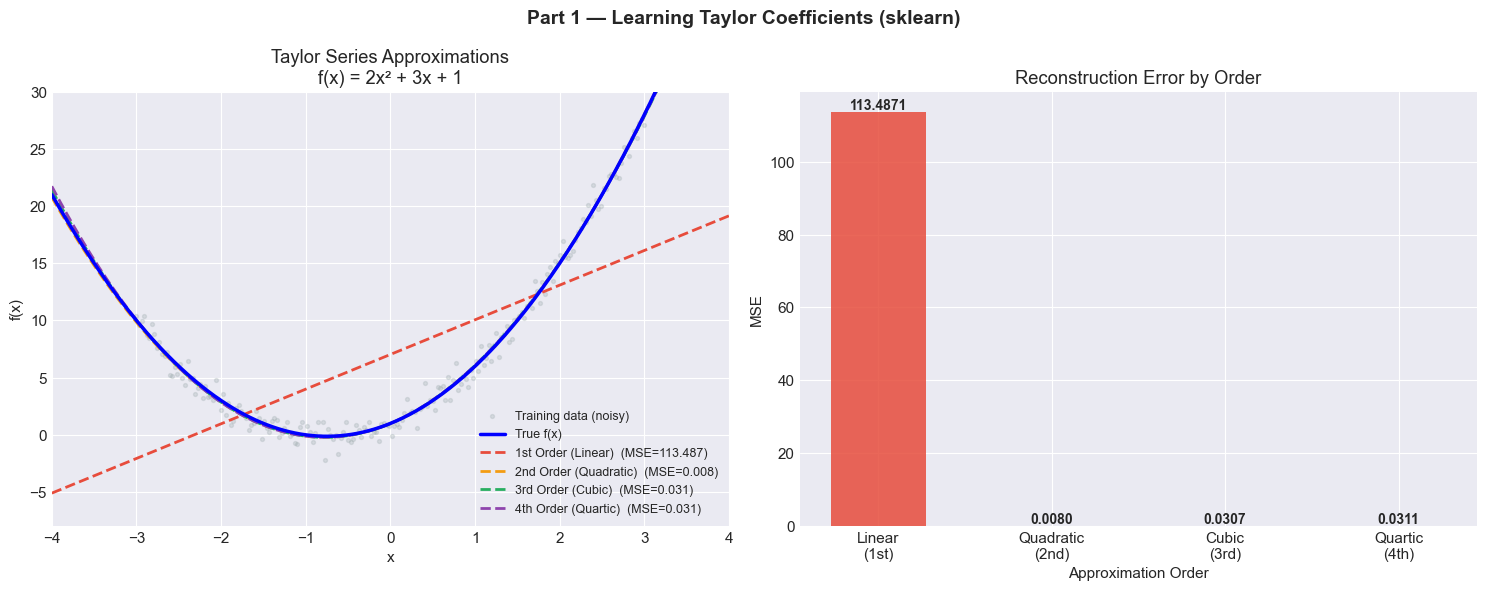

Key: at Order 2 the fit is essentially exact (MSE ≈ noise variance).
     w3 and w4 learned ≈ 0, as predicted analytically.


In [3]:
# ─── Figure 1a: All orders on one canvas + MSE bar ───────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Left — overlay
ax1.scatter(x_train, y_train, s=8, alpha=0.25, color='#95a5a6', label='Training data (noisy)')
ax1.plot(x_plot, y_true, 'b-', lw=2.5, label='True f(x)', zorder=5)
for o in ORDERS:
    ax1.plot(x_plot, sk_preds[o], color=COLORS[o], lw=2, ls='--',
             label=f'{ORDER_LABELS[o]}  (MSE={sk_mse[o]:.3f})')
ax1.set(xlim=(-4,4), ylim=(-8,30), xlabel='x', ylabel='f(x)',
        title='Taylor Series Approximations\nf(x) = 2x² + 3x + 1')
ax1.legend(fontsize=9)

# Right — MSE bar
bars = ax2.bar(ORDERS, [sk_mse[o] for o in ORDERS],
               color=[COLORS[o] for o in ORDERS], alpha=0.85, width=0.55)
for bar, o in zip(bars, ORDERS):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003,
             f'{sk_mse[o]:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax2.set(xlabel='Approximation Order', ylabel='MSE',
        title='Reconstruction Error by Order')
ax2.set_xticks(ORDERS)
ax2.set_xticklabels(['Linear\n(1st)', 'Quadratic\n(2nd)', 'Cubic\n(3rd)', 'Quartic\n(4th)'])

plt.suptitle('Part 1 — Learning Taylor Coefficients (sklearn)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig1_quadratic_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("Key: at Order 2 the fit is essentially exact (MSE ≈ noise variance).")
print("     w3 and w4 learned ≈ 0, as predicted analytically.")


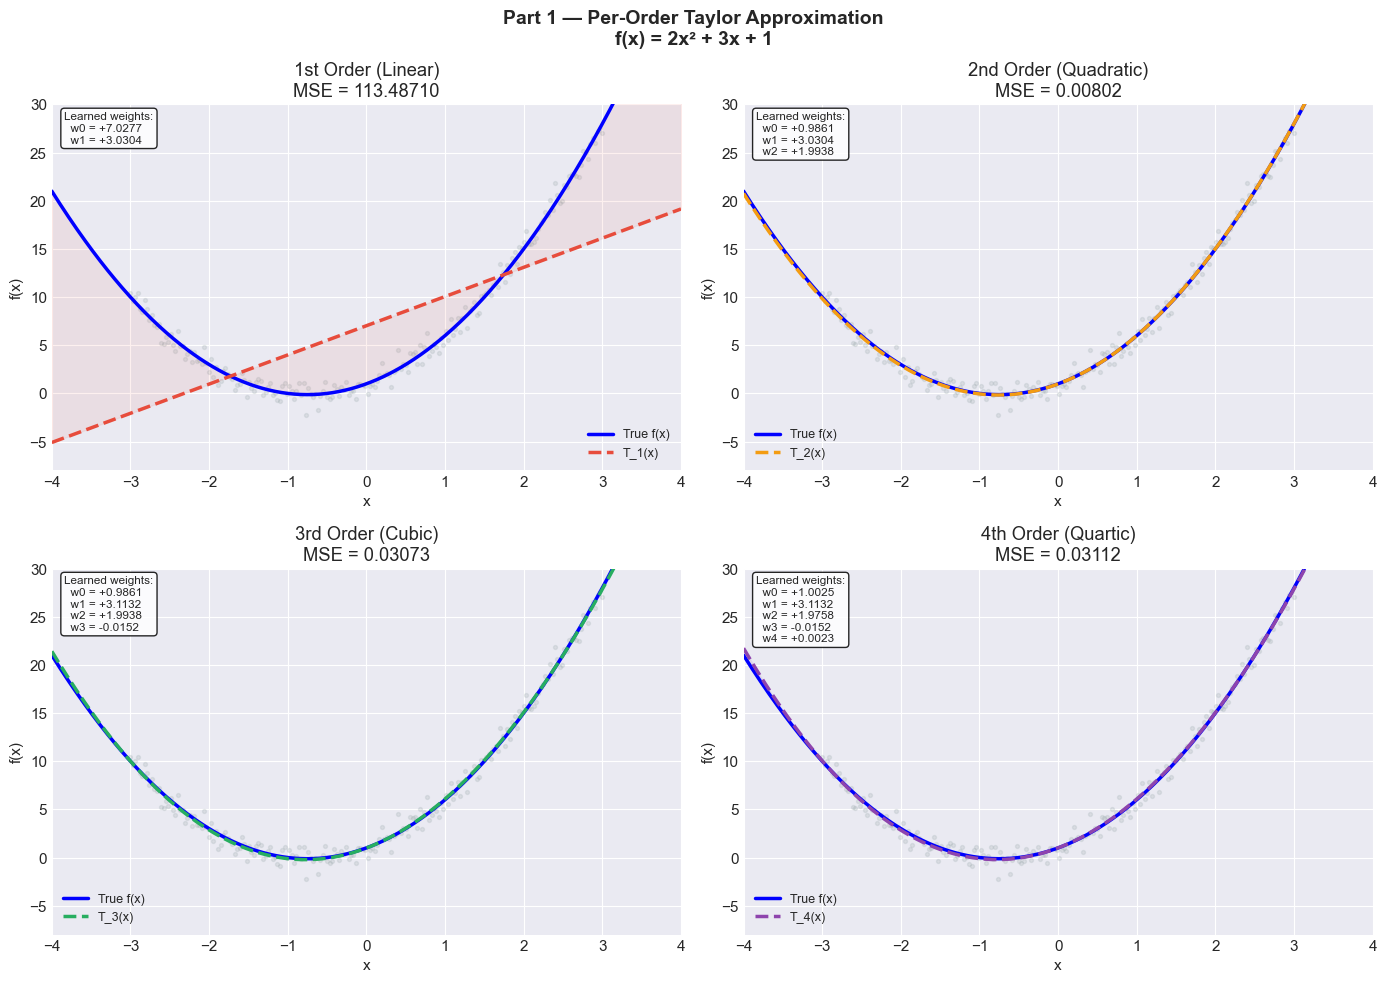

In [4]:
# ─── Figure 1b: 2×2 per-order detail ────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, o in enumerate(ORDERS):
    ax = axes[idx]
    ax.scatter(x_train, y_train, s=8, alpha=0.2, color='#95a5a6')
    ax.plot(x_plot, y_true, 'b-', lw=2.5, label='True f(x)', zorder=4)
    ax.plot(x_plot, sk_preds[o], color=COLORS[o], lw=2.5, ls='--',
            label=f'T_{o}(x)', zorder=5)
    ax.fill_between(x_plot, y_true, sk_preds[o], alpha=0.08, color=COLORS[o])

    # Annotate learned weights
    w = sk_weights[o]
    txt = 'Learned weights:\n' + '\n'.join(f'  w{i} = {v:+.4f}' for i,v in enumerate(w))
    ax.text(0.02, 0.98, txt, transform=ax.transAxes, fontsize=8.5, va='top',
            bbox=dict(boxstyle='round', fc='white', alpha=0.85))

    ax.set(xlim=(-4,4), ylim=(-8,30), xlabel='x', ylabel='f(x)',
           title=f'{ORDER_LABELS[o]}\nMSE = {sk_mse[o]:.5f}')
    ax.legend(fontsize=9)

plt.suptitle('Part 1 — Per-Order Taylor Approximation\nf(x) = 2x² + 3x + 1',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig1_quadratic_2x2.png', dpi=150, bbox_inches='tight')
plt.show()


---
## Part 2 · Approximating Any Function — $g(x) = e^x$

$e^x$ has an infinite Taylor series:

$$e^x = \sum_{k=0}^{\infty} \frac{x^k}{k!} = 1 + x + \frac{x^2}{2} + \frac{x^3}{6} + \frac{x^4}{24} + \cdots$$

The analytical weights are $w_k = 1/k!$.
We train on $x \in [-2, 2]$ and see whether the model learns these values.


In [5]:
# ─── Define target: e^x ──────────────────────────────────────────────────
def g_exp(x):
    return np.exp(x)

TRUE_EXP_COEFFS = [1/math.factorial(k) for k in range(5)]  # [1, 1, 0.5, 1/6, 1/24]

# Training data
x_tr2  = np.linspace(-2, 2, 200)
y_tr2  = g_exp(x_tr2) + np.random.normal(0, 0.05, len(x_tr2))

x_pl2  = np.linspace(-3, 3, 600)
y_exp  = g_exp(x_pl2)

# Sklearn fit
exp_weights = {}
exp_preds   = {}
exp_mse     = {}

for o in ORDERS:
    poly  = PolynomialFeatures(degree=o, include_bias=True)
    X_tr  = poly.fit_transform(x_tr2.reshape(-1, 1))
    reg   = LinearRegression(fit_intercept=False).fit(X_tr, y_tr2)
    X_pl  = poly.transform(x_pl2.reshape(-1, 1))
    y_hat = reg.predict(X_pl)
    exp_weights[o] = reg.coef_
    exp_preds[o]   = y_hat
    exp_mse[o]     = mean_squared_error(y_exp, y_hat)

# Print coefficient comparison
print("Learned weights vs analytical 1/k! for e^x:")
print(f"{'':12}{'w0':>8}{'w1':>8}{'w2':>8}{'w3':>8}{'w4':>8}   MSE")
print("-" * 65)
print(f"{'Analytical':12}" + "".join(f"{c:8.4f}" for c in TRUE_EXP_COEFFS) + "   —")
for o in ORDERS:
    w   = list(exp_weights[o]) + [None]*(5-len(exp_weights[o]))
    row = "".join(f"{c:8.4f}" if c is not None else f"{'—':>8}" for c in w)
    print(f"{'Order '+str(o):12}{row}   {exp_mse[o]:.6f}")

print("\nObserve: learned w_k converge toward 1/k! as order increases.")


Learned weights vs analytical 1/k! for e^x:
                  w0      w1      w2      w3      w4   MSE
-----------------------------------------------------------------
Analytical    1.0000  1.0000  0.5000  0.1667  0.0417   —
Order 1       1.8275  1.4665       —       —       —   11.618257
Order 2       0.9324  1.4665  0.6647       —       —   3.854155
Order 3       0.9324  0.9701  0.6647  0.2048       —   0.947806
Order 4       1.0078  0.9701  0.4780  0.2048  0.0539   0.175194

Observe: learned w_k converge toward 1/k! as order increases.


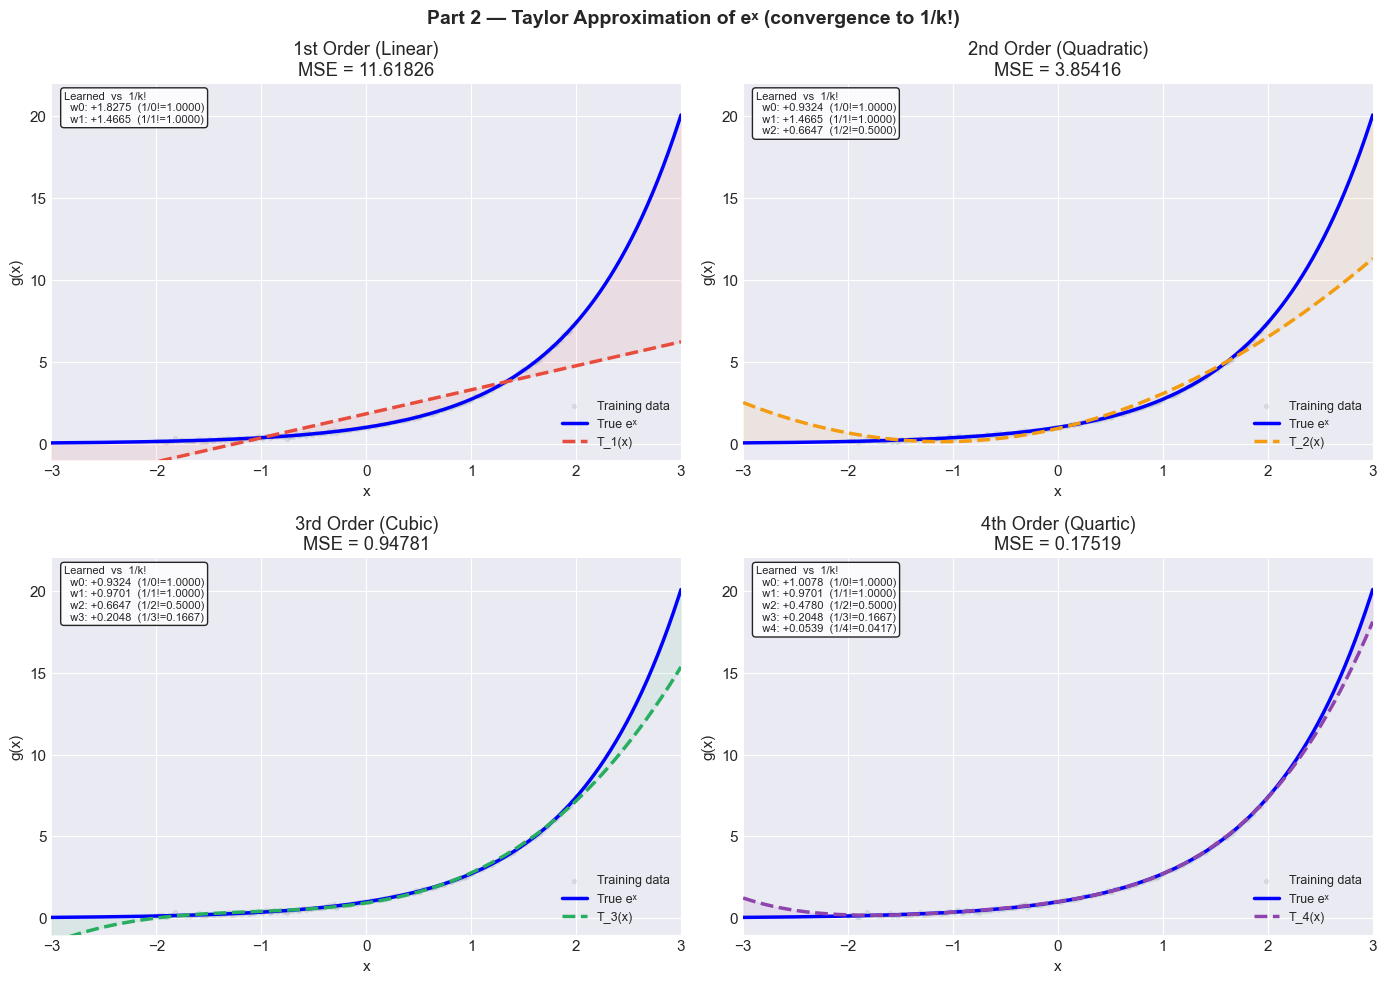

In [6]:
# ─── Figure 2a: e^x approximations 2×2 ──────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, o in enumerate(ORDERS):
    ax = axes[idx]
    ax.scatter(x_tr2, y_tr2, s=8, alpha=0.2, color='#95a5a6', label='Training data')
    ax.plot(x_pl2, y_exp, 'b-', lw=2.5, label='True eˣ', zorder=4)
    ax.plot(x_pl2, exp_preds[o], color=COLORS[o], lw=2.5, ls='--',
            label=f'T_{o}(x)', zorder=5)
    ax.fill_between(x_pl2, y_exp, exp_preds[o], alpha=0.08, color=COLORS[o])

    w = exp_weights[o]
    txt = 'Learned  vs  1/k!\n'
    txt += '\n'.join(f'  w{i}: {v:+.4f}  (1/{i}!={TRUE_EXP_COEFFS[i]:.4f})'
                     for i,v in enumerate(w))
    ax.text(0.02, 0.98, txt, transform=ax.transAxes, fontsize=8, va='top',
            bbox=dict(boxstyle='round', fc='white', alpha=0.85))

    ax.set(xlim=(-3,3), ylim=(-1,22), xlabel='x', ylabel='g(x)',
           title=f'{ORDER_LABELS[o]}\nMSE = {exp_mse[o]:.5f}')
    ax.legend(fontsize=9)

plt.suptitle('Part 2 — Taylor Approximation of eˣ (convergence to 1/k!)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig2_exp_2x2.png', dpi=150, bbox_inches='tight')
plt.show()


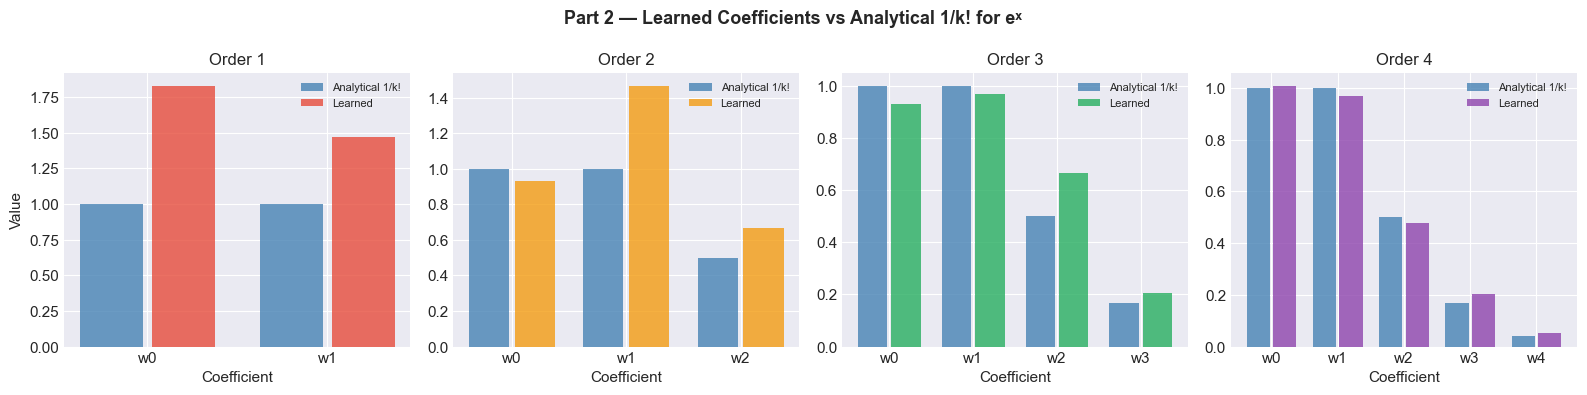

In [7]:
# ─── Figure 2b: coefficient convergence to 1/k! ──────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=False)

for idx, o in enumerate(ORDERS):
    ax = axes[idx]
    w_learned   = exp_weights[o]
    w_true_clip = TRUE_EXP_COEFFS[:o+1]
    ki = np.arange(o+1)

    ax.bar(ki - 0.2, w_true_clip, width=0.35, label='Analytical 1/k!',
           color='steelblue', alpha=0.8)
    ax.bar(ki + 0.2, w_learned,   width=0.35, label='Learned',
           color=COLORS[o], alpha=0.8)
    ax.set_xticks(ki)
    ax.set_xticklabels([f'w{i}' for i in ki])
    ax.set_title(f'Order {o}', fontsize=12)
    ax.set_xlabel('Coefficient')
    if idx == 0:
        ax.set_ylabel('Value')
    ax.legend(fontsize=8)

plt.suptitle('Part 2 — Learned Coefficients vs Analytical 1/k! for eˣ',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig2_exp_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()


---
## Part 3 · Gradient Descent — Learning Weights Iteratively

So far we used sklearn's closed-form solution.
Here we implement **batch gradient descent from scratch** to show the weight-learning process.

### Model & Loss

$$\hat{y} = \mathbf{x}^T \mathbf{w}, \qquad
\mathcal{L} = \frac{1}{N}\sum_i (\hat{y}_i - y_i)^2$$

### Gradient update

$$\nabla_{\mathbf{w}}\mathcal{L} = \frac{2}{N} X^T(\hat{\mathbf{y}} - \mathbf{y}),
\qquad \mathbf{w} \leftarrow \mathbf{w} - \alpha \nabla_{\mathbf{w}}\mathcal{L}$$

where $\alpha$ is the learning rate and $X$ is the Vandermonde (polynomial feature) matrix.


In [8]:
class TaylorRegressor:
    """
    Learns Taylor series weights via batch gradient descent.

    Model  : y_hat = X @ w   (X = Vandermonde matrix [1, x, x^2, ..., x^n])
    Loss   : MSE = mean((y_hat - y)^2)
    Gradient: dL/dw = (2/N) * X.T @ (y_hat - y)
    Update : w ← w - lr * gradient
    """

    def __init__(self, order: int, lr: float = 5e-4, epochs: int = 10_000):
        self.order   = order
        self.lr      = lr
        self.epochs  = epochs
        self.weights = None          # learned Taylor coefficients
        self.loss_history   = []
        self.weight_history = []     # snapshot every 200 epochs

    # ── feature builder (Vandermonde) ────────────────────────────────────────
    def _phi(self, x: np.ndarray) -> np.ndarray:
        """Returns design matrix shape (N, order+1)."""
        return np.column_stack([x**k for k in range(self.order + 1)])

    # ── training loop ─────────────────────────────────────────────────────────
    def fit(self, x: np.ndarray, y: np.ndarray) -> 'TaylorRegressor':
        X = self._phi(x)
        N, D = X.shape
        self.weights = np.random.normal(0, 0.01, D)   # small random init

        for epoch in range(self.epochs):
            y_hat     = X @ self.weights               # forward
            residuals = y_hat - y
            loss      = np.mean(residuals**2)          # MSE
            gradient  = (2 / N) * (X.T @ residuals)   # ∂L/∂w
            self.weights -= self.lr * gradient         # SGD step

            self.loss_history.append(loss)
            if epoch % 200 == 0:
                self.weight_history.append(self.weights.copy())

        return self

    def predict(self, x: np.ndarray) -> np.ndarray:
        return self._phi(x) @ self.weights


print("TaylorRegressor defined.")
print("  Architecture : polynomial features (Vandermonde) → linear layer → MSE loss")
print("  Optimiser    : batch gradient descent")


TaylorRegressor defined.
  Architecture : polynomial features (Vandermonde) → linear layer → MSE loss
  Optimiser    : batch gradient descent


In [9]:
# ─── Train GD models on the quadratic data ────────────────────────────────
gd_models = {}

print("Training (gradient descent) — quadratic target:")
print(f"{'':12}{'Learned weights':40}  Final MSE")
print("-" * 65)

for o in ORDERS:
    m = TaylorRegressor(order=o, lr=5e-4, epochs=12_000)
    m.fit(x_train, y_train)
    gd_models[o] = m

    sk_w = sk_weights[o]
    gd_w = m.weights
    print(f"Order {o}:")
    print(f"  GD     : {np.round(gd_w, 4)}")
    print(f"  sklearn: {np.round(sk_w, 4)}")
    print(f"  MSE    : {m.loss_history[-1]:.6f}")
    print()


Training (gradient descent) — quadratic target:
            Learned weights                           Final MSE
-----------------------------------------------------------------
Order 1:
  GD     : [7.0276 3.0304]
  sklearn: [7.0277 3.0304]
  MSE    : 29.747481

Order 2:
  GD     : [0.9827 3.0304 1.9945]
  sklearn: [0.9861 3.0304 1.9938]
  MSE    : 0.548883

Order 3:
  GD     : [ 0.9827  3.1028  1.9945 -0.0136]
  sklearn: [ 0.9861  3.1132  1.9938 -0.0152]
  MSE    : 0.544976

Order 4:
  GD     : [ 1.0145e+00  3.1029e+00  1.9684e+00 -1.3600e-02  3.1000e-03]
  sklearn: [ 1.0025e+00  3.1132e+00  1.9758e+00 -1.5200e-02  2.3000e-03]
  MSE    : 0.544802



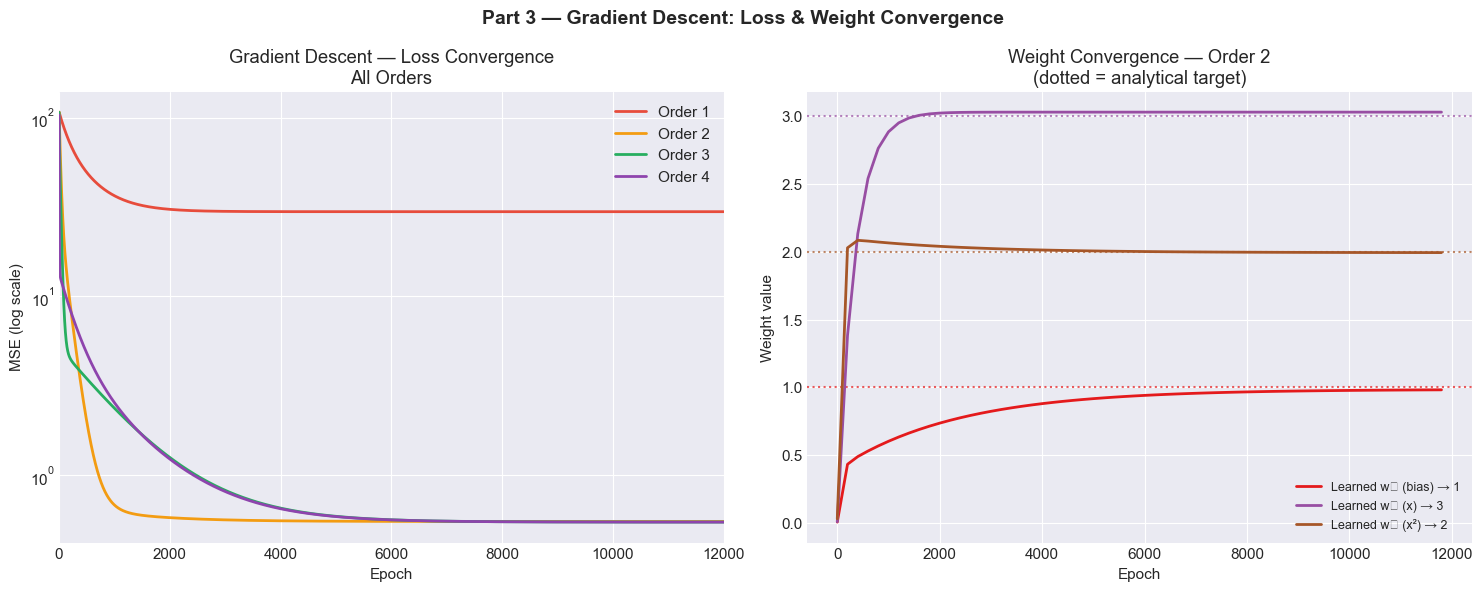

In [10]:
# ─── Figure 3a: loss convergence ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

ax = axes[0]
for o in ORDERS:
    ax.semilogy(gd_models[o].loss_history, color=COLORS[o], lw=2, label=f'Order {o}')
ax.set(xlabel='Epoch', ylabel='MSE (log scale)',
       title='Gradient Descent — Loss Convergence\nAll Orders', xlim=(0, 12000))
ax.legend()

# Weight convergence for order-2 model
ax2 = axes[1]
m2  = gd_models[2]
W   = np.array(m2.weight_history)        # shape (snapshots, 3)
ep  = np.arange(len(W)) * 200

true_w2 = [1, 3, 2]
wlabels  = ['w₀ (bias) → 1', 'w₁ (x) → 3', 'w₂ (x²) → 2']
for j in range(3):
    ax2.plot(ep, W[:, j], lw=2, color=plt.cm.Set1(j/3), label=f'Learned {wlabels[j]}')
    ax2.axhline(true_w2[j], ls=':', lw=1.5, color=plt.cm.Set1(j/3), alpha=0.7)

ax2.set(xlabel='Epoch', ylabel='Weight value',
        title='Weight Convergence — Order 2\n(dotted = analytical target)')
ax2.legend(fontsize=9)

plt.suptitle('Part 3 — Gradient Descent: Loss & Weight Convergence', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig3_gd_convergence.png', dpi=150, bbox_inches='tight')
plt.show()


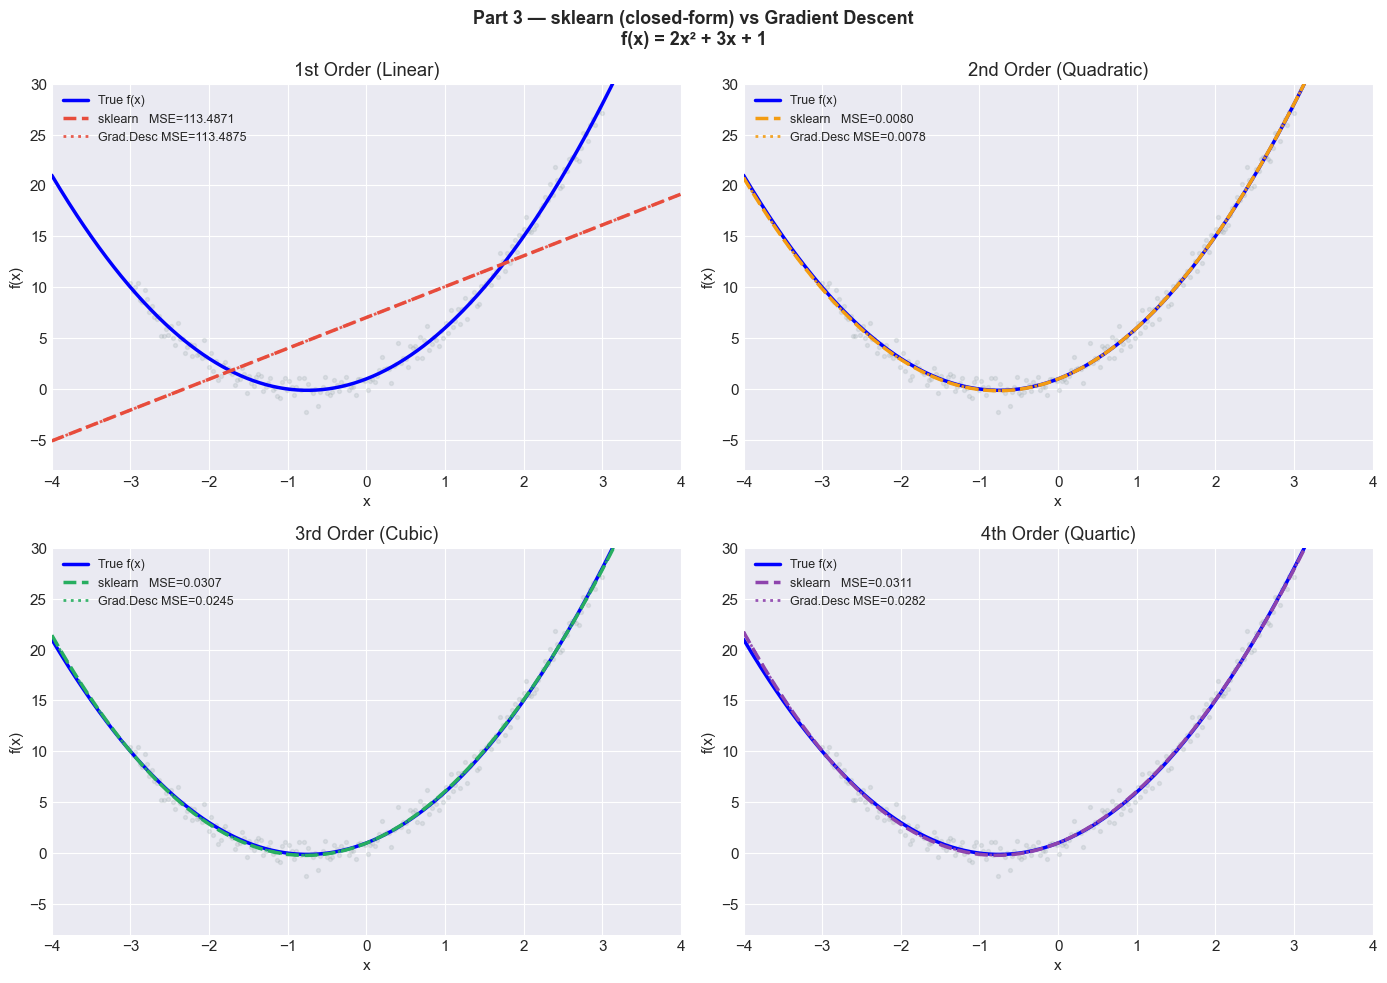

Both methods converge to the same weights — GD just does it iteratively.


In [11]:
# ─── Figure 3b: GD predictions vs sklearn ────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, o in enumerate(ORDERS):
    ax = axes[idx]
    gd_pred = gd_models[o].predict(x_plot)
    sk_pred = sk_preds[o]
    gd_mse  = mean_squared_error(y_true, gd_pred)

    ax.scatter(x_train, y_train, s=8, alpha=0.2, color='#95a5a6')
    ax.plot(x_plot, y_true,  'b-',  lw=2.5,  label='True f(x)')
    ax.plot(x_plot, sk_pred, color=COLORS[o], lw=2.5, ls='--',
            label=f'sklearn   MSE={sk_mse[o]:.4f}', zorder=5)
    ax.plot(x_plot, gd_pred, color=COLORS[o], lw=2,   ls=':',  alpha=0.9,
            label=f'Grad.Desc MSE={gd_mse:.4f}', zorder=4)

    ax.set(xlim=(-4,4), ylim=(-8,30), xlabel='x', ylabel='f(x)',
           title=f'{ORDER_LABELS[o]}')
    ax.legend(fontsize=9)

plt.suptitle('Part 3 — sklearn (closed-form) vs Gradient Descent\nf(x) = 2x² + 3x + 1',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig3_gd_vs_sklearn.png', dpi=150, bbox_inches='tight')
plt.show()
print("Both methods converge to the same weights — GD just does it iteratively.")


---
## Bonus · $\sin(x)$ — Extrapolation Limits

$\sin(x)$ has the Taylor series:

$$\sin(x) = x - \frac{x^3}{3!} + \frac{x^5}{5!} - \cdots$$

Only odd-power terms survive (it is an odd function), so:

| Coeff | Value |
|:---:|:---:|
| $w_0$ | $0$ |
| $w_1$ | $1$ |
| $w_2$ | $0$ |
| $w_3$ | $-1/6 \approx -0.1667$ |
| $w_4$ | $0$ |

We train on $[-\pi, \pi]$ and plot on $[-2\pi, 2\pi]$ to expose where Taylor series break down outside the training window.


In [12]:
# ─── sin(x) training and fitting ─────────────────────────────────────────
TRUE_SIN_COEFFS = [0, 1, 0, -1/math.factorial(3), 0]

x_tr_sin = np.linspace(-np.pi, np.pi, 250)
y_tr_sin  = np.sin(x_tr_sin) + np.random.normal(0, 0.02, len(x_tr_sin))

x_pl_sin  = np.linspace(-2*np.pi, 2*np.pi, 600)
y_sin_true = np.sin(x_pl_sin)

sin_preds  = {}
sin_weights = {}
sin_mse    = {}

for o in ORDERS:
    poly  = PolynomialFeatures(degree=o, include_bias=True)
    X_tr  = poly.fit_transform(x_tr_sin.reshape(-1, 1))
    reg   = LinearRegression(fit_intercept=False).fit(X_tr, y_tr_sin)
    X_pl  = poly.transform(x_pl_sin.reshape(-1, 1))
    y_hat = reg.predict(X_pl)
    sin_weights[o] = reg.coef_
    sin_preds[o]   = y_hat
    # MSE only on training range for fair comparison
    mask = (x_pl_sin >= -np.pi) & (x_pl_sin <= np.pi)
    sin_mse[o] = mean_squared_error(y_sin_true[mask], y_hat[mask])

# Print learned vs analytical
print("Learned weights vs analytical Taylor for sin(x):")
print(f"{'':12}{'w0':>9}{'w1':>9}{'w2':>9}{'w3':>9}{'w4':>9}")
print("-" * 57)
print(f"{'Analytical':12}" + "".join(f"{c:9.4f}" for c in TRUE_SIN_COEFFS))
for o in ORDERS:
    w   = list(sin_weights[o]) + [None]*(5-len(sin_weights[o]))
    row = "".join(f"{c:9.4f}" if c is not None else f"{'—':>9}" for c in w)
    print(f"{'Order '+str(o):12}{row}")


Learned weights vs analytical Taylor for sin(x):
                   w0       w1       w2       w3       w4
---------------------------------------------------------
Analytical     0.0000   1.0000   0.0000  -0.1667   0.0000
Order 1       -0.0008   0.3005        —        —        —
Order 2       -0.0023   0.3005   0.0005        —        —
Order 3       -0.0023   0.8584   0.0005  -0.0935        —
Order 4       -0.0022   0.8584   0.0003  -0.0935   0.0000


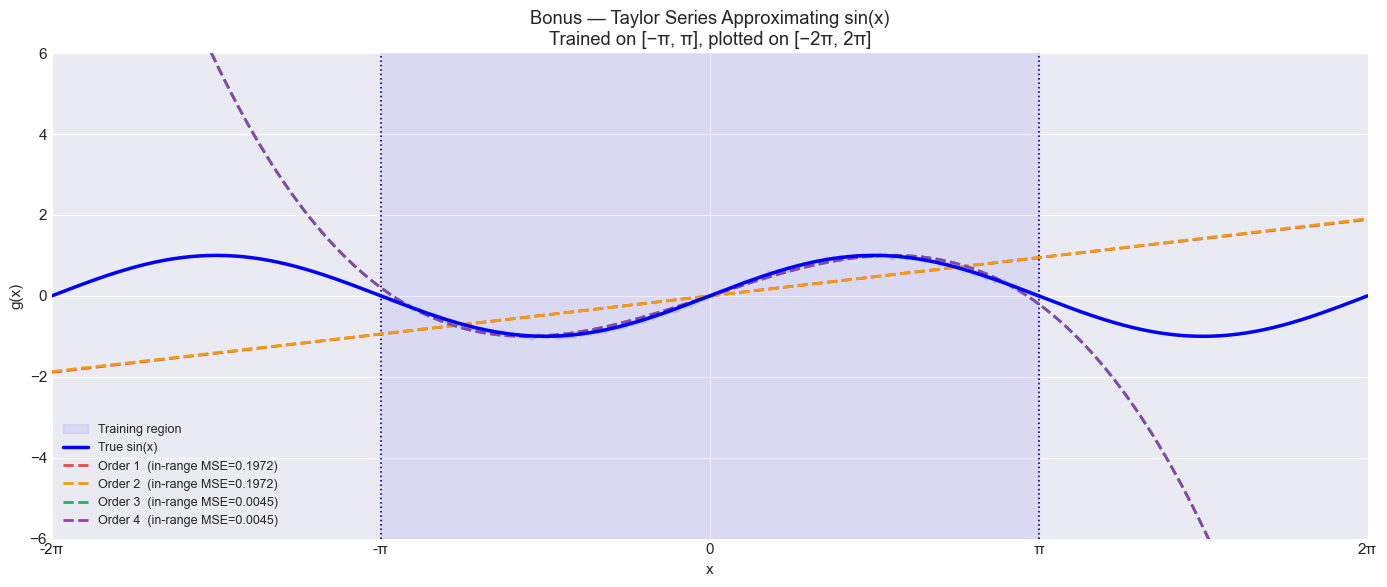

Inside the training window: all orders track sin(x) well.
Outside the window : polynomial Taylor series diverge — the fit is local!


In [13]:
# ─── Figure 4: sin(x) with training / test boundary ─────────────────────
fig, ax = plt.subplots(figsize=(14, 6))

# Shade training region
ax.axvspan(-np.pi, np.pi, alpha=0.07, color='blue', label='Training region')
ax.axvline(-np.pi, color='navy', ls=':', lw=1.2)
ax.axvline( np.pi, color='navy', ls=':', lw=1.2)

ax.scatter(x_tr_sin, y_tr_sin, s=6, alpha=0.25, color='#95a5a6')
ax.plot(x_pl_sin, y_sin_true, 'b-', lw=2.5, label='True sin(x)', zorder=5)

for o in ORDERS:
    ax.plot(x_pl_sin, sin_preds[o], color=COLORS[o], lw=2, ls='--',
            label=f'Order {o}  (in-range MSE={sin_mse[o]:.4f})')

ax.set(xlim=(-2*np.pi, 2*np.pi), ylim=(-6, 6),
       xlabel='x', ylabel='g(x)',
       title='Bonus — Taylor Series Approximating sin(x)\n'
             'Trained on [−π, π], plotted on [−2π, 2π]')
ax.set_xticks([-2*np.pi, -np.pi, 0, np.pi, 2*np.pi])
ax.set_xticklabels(['-2π', '-π', '0', 'π', '2π'])
ax.legend(fontsize=9, loc='lower left')

plt.tight_layout()
plt.savefig('fig4_sin_extrapolation.png', dpi=150, bbox_inches='tight')
plt.show()

print("Inside the training window: all orders track sin(x) well.")
print("Outside the window : polynomial Taylor series diverge — the fit is local!")


---
## Summary

| Concept | What we showed |
|:---|:---|
| **Taylor series** | Any smooth function ≈ polynomial near $x_0$ |
| **Order 1** | Linear fit — captures slope but misses curvature |
| **Order 2** | Exact for quadratics; good first correction for $e^x$, $\sin x$ |
| **Order 3 & 4** | Better approximation of transcendental functions |
| **Learning weights** | Polynomial regression = closed-form; Gradient descent = iterative |
| **Extrapolation** | Taylor series are *local* — diverge outside the training window |

### Takeaway

> *The Taylor series is a universal basis for smooth functions.
> Learning its weights from data is exactly what a polynomial regression (or a neural network
> with polynomial activations) does internally.*
